## Introduction to AI-Powered services in ArcGIS Online

ArcGIS Online comes equipped with AI-powered services, supported in the ArcGIS API for Python via the [`arcgis.ai`](https://developers.arcgis.com/python/latest/api-reference/arcgis.ai.html) module. It is designed to extract valuable information and help automate tasks involving unstructured content, such as text, images, and documents.

The API supports three services or methods:
1. [`analyze_image()`](https://developers.arcgis.com/python/latest/api-reference/arcgis.ai.html#analyze-image) - Analyzes images based on the user provided instructions.
2. [`analyze_text()`](https://developers.arcgis.com/python/latest/api-reference/arcgis.ai.html#analyze-text) - Analyzes provided text against the specified context.
3. [`translate()`](https://developers.arcgis.com/python/latest/api-reference/arcgis.ai.html#translate) - Translates language strings.

We will explore these methods through a generic example, as well as examples involving ArcGIS items to see potential uses of these AI services applicable to our ArcGIS data.

> Note: Using these services consumes credits:
> 1. `analyze_image()` - __5 images per credit__
> 2. `analyze_text()` - __5,000 characters per credit__
> 3. `translate()` - __1,000 characters per credit__

In [3]:
from arcgis.gis import GIS
from arcgis.ai import analyze_image, analyze_text, translate, AIUtilsResponse

In [4]:
gis = GIS(profile='your_online_profile')

### __Analyze Image__

This tool helps analyze images using AI-powered models for object detection, text extraction, image description, and segmentation. Currently supported image formats are: JPEG, PNG and WEBP.

> Note: Input image could be provided as an URL or Base64. Only images hosted on *.arcgis.com domains are supported via url input. 


Let us start with this image hosted in ArcGIS Online.

![image](https://github.com/user-attachments/assets/e94eaad2-d6e6-4b82-b726-93b312167d95)

In [25]:
image_url = "https://geosaurus.maps.arcgis.com/sharing/rest/content/items/6e9ff93df28a4231b4bd6e729ce42898/data"

Prompts to the `analyze_image()` method may be provided as string, list or dictionary inputs. We will see examples for all 3 below. 

#### 1. Prompt as `str` input

In [21]:
prompt_str = "List all the colors present in the image."

In [22]:
colors = analyze_image(image = image_url, prompt = prompt_str)
colors

AIUtilsResponse(success=True, meta=AIUtilsResponseMetaData(usage={'inputTokens': 1831, 'outputTokens': 62, 'totalTokens': 1893}, model='gpt-5.4'), results=[AnalyzeResult(success=True, value=['green', 'dark green', 'light green', 'brown', 'dark brown', 'orange', 'yellow', 'red', 'pink', 'purple', 'blue', 'black', 'gray', 'white'], key='unique_string_1')])

As we will continue to see through this guide, the results generated from running these tools in the ArcGIS API for Python are of [`AIUtilsResponse`](https://developers.arcgis.com/python/latest/api-reference/arcgis.ai.html#arcgis.ai.AIUtilsResponse) type. 

You can verify if the request was successful using the `success` field of the response as shown below. 

In [23]:
colors.success

True

Since `AIUtilsResponse` is a pydantic model, you can access the specific results of the response as shown below.

In [24]:
colors.results[0].value

['green',
 'dark green',
 'light green',
 'brown',
 'dark brown',
 'orange',
 'yellow',
 'red',
 'pink',
 'purple',
 'blue',
 'black',
 'gray',
 'white']

The service has correctly identified the colors in this image.

We will now proceed to see examples involving the other input types through an ArcGIS item. This is a [map image](https://www.arcgis.com/home/item.html?id=36c34ac9e2c5402ab94762f97f3349af#overview) representing the hurricane history for Virginia. 

![virginia_map](https://geosaurus.maps.arcgis.com/sharing/rest/content/items/36c34ac9e2c5402ab94762f97f3349af/data)

In [30]:
virginia_map_url = "https://geosaurus.maps.arcgis.com/sharing/rest/content/items/36c34ac9e2c5402ab94762f97f3349af/data"

#### 2. Prompt as `list` input

In [44]:
prompt_list = [
    "Describe the image.",
    "Identify any hurricane related text in the image."
]

In [45]:
result_list = analyze_image(image = virginia_map_url, prompt = prompt_list)
result_list

AIUtilsResponse(success=True, meta=AIUtilsResponseMetaData(usage={'inputTokens': 1822, 'outputTokens': 448, 'totalTokens': 2270}, model='gpt-5.4'), results=[AnalyzeResult(success=True, value='A grayscale map of Virginia showing hurricane, tropical storm, and tropical depression tracks across the state and nearby Atlantic coast. The title reads "Virginia Hurricanes, Tropical Storms, and Tropical Depressions by Date 1852-2016, 2017-2021." Many storm paths are drawn in light blue for 1852-2016 and in orange/red shades for 2017-2021. County boundaries, neighboring states, a mileage scale, north arrow, legend, and source information are also shown.', key='unique_string_0'), AnalyzeResult(success=True, value=['Virginia Hurricanes, Tropical Storms, and Tropical Depressions by Date 1852-2016, 2017-2021', 'Hurricane Category 2, 2017-2021', 'Tropical Storm, 2017-2021', 'Tropical Depression 2017-2021', 'Hurricane Category 4, 1852-2016', 'Hurricane Category 3, 1852-2016', 'Hurricane Category 2, 18

We can access results for the individual prompts via the prompt index provided to the `results` field as demonstrated below.

In [46]:
result_list.results[0].value

'A grayscale map of Virginia showing hurricane, tropical storm, and tropical depression tracks across the state and nearby Atlantic coast. The title reads "Virginia Hurricanes, Tropical Storms, and Tropical Depressions by Date 1852-2016, 2017-2021." Many storm paths are drawn in light blue for 1852-2016 and in orange/red shades for 2017-2021. County boundaries, neighboring states, a mileage scale, north arrow, legend, and source information are also shown.'

In [47]:
result_list.results[1].value

['Virginia Hurricanes, Tropical Storms, and Tropical Depressions by Date 1852-2016, 2017-2021',
 'Hurricane Category 2, 2017-2021',
 'Tropical Storm, 2017-2021',
 'Tropical Depression 2017-2021',
 'Hurricane Category 4, 1852-2016',
 'Hurricane Category 3, 1852-2016',
 'Hurricane Category 2, 1852-2016',
 'Hurricane Category 1, 1852-2016',
 'Tropical Storm, 1852-2016',
 'Tropical Depression, 1852-2016',
 'FLORENCE, 2018',
 'IDA, 2021',
 'ZETA, 2020',
 'BERTHA, 2020',
 'MICHAEL, 2018',
 'ELSA, 2021',
 'ISAIAS, 2020',
 'FAY, 2020',
 'CLAUDETTE, 2021',
 'DORIAN, 2019',
 'FRED, 2021']

The response provides a succinct summary of this map and extracts key information regarding hurricanes referenced. 

#### 3. Prompt as `dict` input 

In order to provide prompts as a dictionary, it is essential to provide the values for the `key` and `context` keys of the dictionary for each prompt that you wish to provide. 

In [40]:
prompt_dicts = [
    {"key": "images_prompt", "context": "How many sub-boundaries of Virginia are included in the image?"},
    {"key": "text_prompt", "context": "Identify the states named in the map."}
]

In [41]:
result_dicts = analyze_image(image = virginia_map_url, prompt = prompt_dicts)
result_dicts

AIUtilsResponse(success=True, meta=AIUtilsResponseMetaData(usage={'inputTokens': 1826, 'outputTokens': 117, 'totalTokens': 1943}, model='gpt-5.4'), results=[AnalyzeResult(success=True, value=95, key='images_prompt'), AnalyzeResult(success=True, value=['Ohio', 'Pennsylvania', 'Maryland', 'Delaware', 'Kentucky', 'Tennessee', 'North Carolina', 'Virginia'], key='text_prompt')])

In [42]:
result_dicts.results[0].value

95

In [43]:
dicts_result.results[1].value

['Ohio',
 'Pennsylvania',
 'Maryland',
 'Delaware',
 'Kentucky',
 'Tennessee',
 'North Carolina',
 'Virginia']

The tool here currently identifies 95 sub-boundaries (counties) for Virginia, and detects all the states mentioned in the map image. 

### __Analyze Text__

This tool analyzes the provided text against the given prompt(s) using AI capabilities. Users are allowed to submit text for analysis, which can include tasks such as sentiment analysis, entity recognition, and other natural language processing operations.

Similar to the `analyze_image()` method, prompts to the `analyze_text()` method may be provided as string, list or dictionary inputs. We will see examples for all 3 input types below. 

#### 1. Prompt as `str` input

In [48]:
sample_text = "During our recent travels, we explored bustling city centers like London and Prague, \
            wandered through the ancient, narrow streets of Rome, and relaxed on the sunny beaches of \
            Alanya near the historic Alanya Castle. We visited the majestic Taj Mahal in Agra, toured the \
            expansive Amber Palace in Jaipur, and took a relaxing break by the calm waters of the Dim River."

prompt_str = "Detect all locations in this text"

In [50]:
locations = analyze_text(text = sample_text, prompt = prompt_str)
locations

AIUtilsResponse(success=True, meta=AIUtilsResponseMetaData(usage={'inputTokens': 750, 'outputTokens': 55, 'totalTokens': 805}, model='gpt-5.4'), results=[AnalyzeResult(success=True, value=['London', 'Prague', 'Rome', 'Alanya', 'Alanya Castle', 'Taj Mahal', 'Agra', 'Amber Palace', 'Jaipur', 'Dim River'], key='key:1')])

In [51]:
locations.results[0].value

['London',
 'Prague',
 'Rome',
 'Alanya',
 'Alanya Castle',
 'Taj Mahal',
 'Agra',
 'Amber Palace',
 'Jaipur',
 'Dim River']

#### 2. Prompt as `list` input

In [60]:
prompt_list = [
    "Detect the sentiment of the text.",
    "Identify countries in the text."
]

In [61]:
result_list = analyze_text(text = sample_text, prompt = prompt_list)
result_list

AIUtilsResponse(success=True, meta=AIUtilsResponseMetaData(usage={'inputTokens': 768, 'outputTokens': 54, 'totalTokens': 822}, model='gpt-5.4'), results=[AnalyzeResult(success=True, value='positive', key='unique_string_0'), AnalyzeResult(success=True, value=['United Kingdom', 'Czech Republic', 'Italy', 'Turkey', 'India'], key='unique_string_1')])

We can access results for the individual prompts via the prompt index provided to the `results` field as demonstrated below.

In [62]:
result_list.results[0].value

'positive'

In [63]:
result_list.results[1].value

['United Kingdom', 'Czech Republic', 'Italy', 'Turkey', 'India']

#### 3. Prompt as `dict` input

We will now look at an example that uses a dictionary of prompt inputs using an ArcGIS item. This is a [document](https://www.arcgis.com/home/item.html?id=c7b4e9240149481ea69af628513962fe#overview) about Esri's Water Resources. Let us learn more about this item. 

<Item title:"Esri - Water Resources" type:Document Link owner:NSGIC_Dev1>
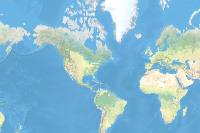

In [66]:
document = gis.content.get('c7b4e9240149481ea69af628513962fe')
document

We extract the description of this item using the `description` property of the `Item` and pass it as the text input to our method. 

In [67]:
item_description = document.description
item_description

"<div>Esri's Water Resources GIS Platform offers a comprehensive suite of tools and resources designed to modernize water resource management. It emphasizes geospatial solutions for monitoring, analyzing, and modeling water systems, helping decision-makers tackle challenges like drought resilience, flood mitigation, and environmental protection. By leveraging the capabilities of ArcGIS, users can transform raw water data into actionable insights, ensuring more efficient and effective water resource management.</div><div><br /></div><div>A central feature of the platform is Arc Hydro, a specialized data model and toolkit developed for GIS-based water resource analysis. This toolset allows users to integrate, analyze, and visualize water datasets for applications ranging from live stream gauge monitoring to pollution control. Additionally, the platform connects users to the ArcGIS Living Atlas of the World, which offers extensive water-related datasets such as rivers, wetlands, and soils

Similar to the `analyze_image()` method, in order to provide prompts as a dictionary it is essential to provide the values for the key and context keys of the dictionary for each prompt that you wish to provide.

In [68]:
prompt_dicts = [
    {"key": "summary_prompt", "context": "Summarize this text"},
    {"key": "tools_prompt", "context": "Identify the tools mentioned in the text."}
]

In [69]:
result_dicts = analyze_text(text = item_description, prompt = prompt_dicts)
result_dicts

AIUtilsResponse(success=True, meta=AIUtilsResponseMetaData(usage={'inputTokens': 997, 'outputTokens': 140, 'totalTokens': 1137}, model='gpt-5.4'), results=[AnalyzeResult(success=True, value="Esri's Water Resources GIS Platform provides geospatial tools, datasets, training, and community resources to improve water resource management. It uses ArcGIS capabilities to monitor, analyze, and model water systems for issues such as drought resilience, flood mitigation, and environmental protection. Key components include Arc Hydro for GIS-based water analysis, the ArcGIS Living Atlas of the World for water-related datasets, and the Hydro Community for collaboration and knowledge sharing.", key='summary_prompt'), AnalyzeResult(success=True, value=['ArcGIS', 'Arc Hydro', 'ArcGIS Living Atlas of the World', 'Hydro Community'], key='tools_prompt')])

In [70]:
result_dicts.results[0].value

"Esri's Water Resources GIS Platform provides geospatial tools, datasets, training, and community resources to improve water resource management. It uses ArcGIS capabilities to monitor, analyze, and model water systems for issues such as drought resilience, flood mitigation, and environmental protection. Key components include Arc Hydro for GIS-based water analysis, the ArcGIS Living Atlas of the World for water-related datasets, and the Hydro Community for collaboration and knowledge sharing."

In [71]:
result_dicts.results[1].value

['ArcGIS', 'Arc Hydro', 'ArcGIS Living Atlas of the World', 'Hydro Community']

The tool summarizes the description of this item well and also identifies the ArcGIS tools mentioned. 

### __Translate Text__

The `translate()` method translates language strings passed to the desired array of output cultures. To identify the languages supported in your ArcGIS Online Organization and the `culture` of those languages, you may invoke the `languages` property of the `GIS` object as shown below.

In [73]:
gis.languages

[{'language': 'Arabic', 'culture': 'ar', 'localizedName': 'عربي'},
 {'language': 'Bosnian', 'culture': 'bs', 'localizedName': 'Bosanski'},
 {'language': 'Bulgarian', 'culture': 'bg', 'localizedName': 'Български'},
 {'language': 'Simplified Chinese',
  'culture': 'zh-CN',
  'localizedName': '简体中文'},
 {'language': 'Catalan', 'culture': 'ca', 'localizedName': 'Català'},
 {'language': 'Croatian', 'culture': 'hr', 'localizedName': 'Hrvatski'},
 {'language': 'Czech', 'culture': 'cs', 'localizedName': 'čeština'},
 {'language': 'Danish', 'culture': 'da', 'localizedName': 'Dansk'},
 {'language': 'Dutch', 'culture': 'nl', 'localizedName': 'Nederlands'},
 {'language': 'English',
  'culture': 'en',
  'localizedName': 'English',
  'cultureFormats': [{'name': 'United States',
    'localizedName': 'United States',
    'format': 'us'},
   {'name': 'Great Britain', 'localizedName': 'Great Britain', 'format': 'gb'},
   {'name': 'Australia', 'localizedName': 'Australia', 'format': 'au'},
   {'name': 'Can

We start with an example to translate a few lines in Spanish to English.

In [72]:
text = "El bosque está lleno de vida. Mientras el sol brilla a través de las altas ramas, el viento sopla suavemente. Los \
        pájaros cantan en los árboles y las mariposas vuelan sobre las flores. Estar en la naturaleza nos da paz y tranquilidad."

Note that the input to the `to_language` parameter in the `translate()` method accepts input as a `list`, to support multiple output languages at once. However, the `from_language` parameter accepts a `str` input. 

In [75]:
spanish_to_english = translate(text = text, to_language = ['en'], from_language = 'es')
spanish_to_english

AIUtilsResponse(success=True, meta=AIUtilsResponseMetaData(usage={'inputCharacters': 242}, model='azure-ai-translator'), results=[TranslateResult(translations=[{'text': 'The forest is full of life. As the sun shines through the tall branches, the wind blows gently. Birds sing in the trees and butterflies fly over the flowers. Being in nature gives us peace and tranquility.', 'to': 'en'}], key='key:1')])

Unlike the `analyze_image()` and `analyze_text()` methods, the process to access the response (translated text) is slightly different, as shown below.

In [80]:
spanish_to_english.results[0].translations[0]['text']

'The forest is full of life. As the sun shines through the tall branches, the wind blows gently. Birds sing in the trees and butterflies fly over the flowers. Being in nature gives us peace and tranquility.'

Let us conclude with an example using an ArcGIS item from Ontario, Canada in French. We fetch the item and access its `snippet` which we provide as input to the `translate()` method. 

<Item title:"Données du rapport annuel historique sur les forêts de l’Ontario" type:Document Link owner:LandInformationOntario>
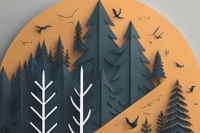

In [81]:
ontario_canada_item = gis.content.get('9c2e4d1a671f41eb913411f048aaf661')
ontario_canada_item

In [82]:
item_snippet = ontario_canada_item.snippet
item_snippet

'Les données du rapport annuel historique sur les forêts de l’Ontario constituent un ensemble de données consolidées à l’échelle de la province, provenant des rapports annuels sur les opérations forestières depuis 2002. Format des données :  ESRI Geodatabase'

In [83]:
french_to_english = translate(text = item_snippet, to_language = ['en'], from_language = 'fr')
french_to_english

AIUtilsResponse(success=True, meta=AIUtilsResponseMetaData(usage={'inputCharacters': 257}, model='azure-ai-translator'), results=[TranslateResult(translations=[{'text': 'The Ontario Historical Annual Forest Report is a province-wide consolidated dataset from annual reports on forest operations since 2002. Data Format: ESRI Geodatabase', 'to': 'en'}], key='key:1')])

In [85]:
french_to_english.results[0].translations[0]['text']

'The Ontario Historical Annual Forest Report is a province-wide consolidated dataset from annual reports on forest operations since 2002. Data Format: ESRI Geodatabase'

We see that the tool has successfully translated the snippet from French to English.

### Conclusion

The `arcgis.ai` module is useful when your workflows involve unstructured data in the form of field notes, inspection reports, public comments, customer requests, attached photos or scanned documents. Deriving necessary information from these data sources using these services supported within the ArcGIS API for Python can improve productivity. 

To delve deeper into the `arcgis.ai` module with an example that involves real-world data, we encourage you to take a look at this [sample](https://developers.arcgis.com/python/latest/samples/ai-utility-services-enhancing-service-requests/). 